# Descriptive Charts: AI Exposure Trends & Index Distributions
Two things in this notebook:
1. Employment/wage trends by exposure group, **2020–2021 excluded** (matches the regression sample)
2. Distribution of LM_AIOE and MS_SCORE, plus a scatter showing their correlation


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ------------------------------------------------------------------
# Load data — adjust filename/columns if yours differ.
# Needs: year, OCC_CODE, TOT_EMP, A_MEDIAN, LM_AIOE, MS_SCORE
# ------------------------------------------------------------------
df = pd.read_csv('bls_onet_felten_ms_panel_harmonised.csv')

# If MS_SCORE lives in a separate file, merge it in here, e.g.:
# ms = pd.read_csv('ms_score_by_occupation.csv')
# df = df.merge(ms[['OCC_CODE', 'MS_SCORE']], on='OCC_CODE', how='left')

# Drop COVID years entirely — not shown, not analyzed
df = df[~df['year'].isin([2020, 2021])].copy()

df['TOT_EMP'] = pd.to_numeric(df['TOT_EMP'], errors='coerce')
df['A_MEDIAN'] = pd.to_numeric(df['A_MEDIAN'], errors='coerce')

print(f"Rows after dropping 2020-2021: {len(df)}")
print(f"Years remaining: {sorted(df['year'].unique())}")


Rows after dropping 2020-2021: 166422
Years remaining: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


## Step 1: high/low exposure split (median split on LM_AIOE, same as the SC notebooks)

In [2]:
aioe_by_occ = df.groupby('OCC_CODE')['LM_AIOE'].first()
median_aioe = aioe_by_occ.median()

df['exposure_group'] = np.where(
    df['OCC_CODE'].map(aioe_by_occ) >= median_aioe, 'High Exposure', 'Low Exposure'
)

colors = {'High Exposure': '#C0392B', 'Low Exposure': '#2980B9'}
print(f"AIOE median: {median_aioe:.4f}")
print(df['exposure_group'].value_counts())


AIOE median: -0.1161
exposure_group
Low Exposure     91447
High Exposure    74975
Name: count, dtype: int64


## Step 2: Employment trend, indexed to 2018 = 100 (COVID years excluded)

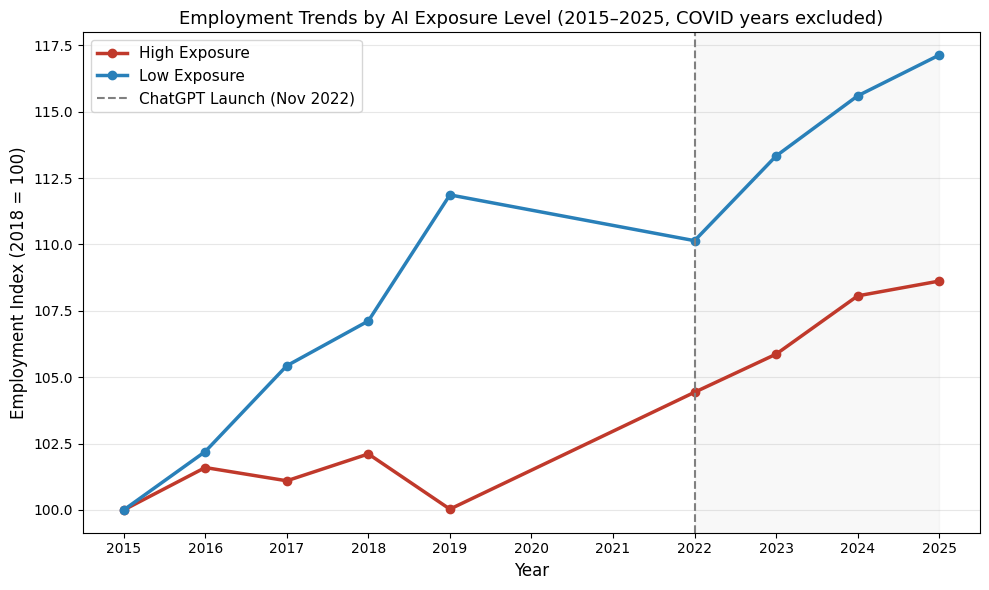

Saved descriptive_employment_trend.png


In [7]:
emp_agg = (
    df.groupby(['year', 'exposure_group'])['TOT_EMP']
    .sum()
    .reset_index()
)

base_emp = emp_agg[emp_agg['year'] == 2015].set_index('exposure_group')['TOT_EMP']
emp_agg['emp_index'] = emp_agg.apply(
    lambda row: row['TOT_EMP'] / base_emp[row['exposure_group']] * 100, axis=1
)

fig, ax = plt.subplots(figsize=(10, 6))
for group, gdf in emp_agg.groupby('exposure_group'):
    gdf = gdf.sort_values('year')
    ax.plot(gdf['year'], gdf['emp_index'],
            label=group, color=colors[group],
            linewidth=2.5, marker='o', markersize=6)

ax.axvline(x=2022, color='gray', linestyle='--', linewidth=1.5, label='ChatGPT Launch (Nov 2022)')
ax.axvspan(2022, 2025, alpha=0.05, color='gray')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Employment Index (2018 = 100)', fontsize=12)
ax.set_title('Employment Trends by AI Exposure Level (2015–2025, COVID years excluded)', fontsize=13)
ax.legend(fontsize=11)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('descriptive_employment_trend.png', dpi=150)
plt.show()
print('Saved descriptive_employment_trend.png')


## Step 3: Wage trend, same treatment (COVID years excluded)

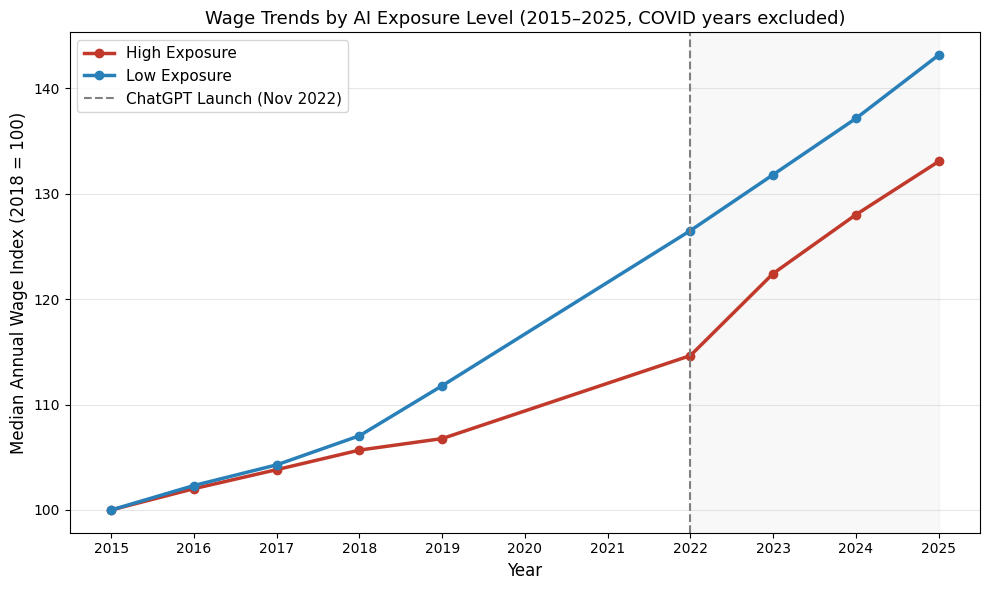

Saved descriptive_wage_trend.png


In [8]:
wage_agg = (
    df.groupby(['year', 'exposure_group'])['A_MEDIAN']
    .median()
    .reset_index()
)

base_wage = wage_agg[wage_agg['year'] == 2015].set_index('exposure_group')['A_MEDIAN']
wage_agg['wage_index'] = wage_agg.apply(
    lambda row: row['A_MEDIAN'] / base_wage[row['exposure_group']] * 100, axis=1
)

fig, ax = plt.subplots(figsize=(10, 6))
for group, gdf in wage_agg.groupby('exposure_group'):
    gdf = gdf.sort_values('year')
    ax.plot(gdf['year'], gdf['wage_index'],
            label=group, color=colors[group],
            linewidth=2.5, marker='o', markersize=6)

ax.axvline(x=2022, color='gray', linestyle='--', linewidth=1.5, label='ChatGPT Launch (Nov 2022)')
ax.axvspan(2022, 2025, alpha=0.05, color='gray')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Median Annual Wage Index (2018 = 100)', fontsize=12)
ax.set_title('Wage Trends by AI Exposure Level (2015–2025, COVID years excluded)', fontsize=13)
ax.legend(fontsize=11)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('descriptive_wage_trend.png', dpi=150)
plt.show()
print('Saved descriptive_wage_trend.png')


## Step 4: Index distributions — LM_AIOE and MS_SCORE
One occupation should appear once here, not once per occupation-year row, so we deduplicate first.

Unique occupations with both indices: 670


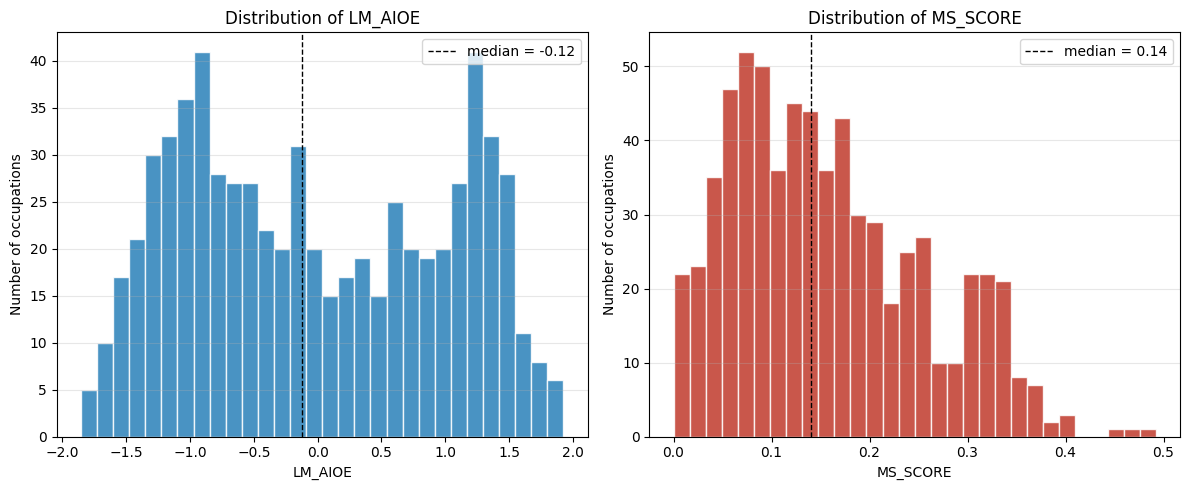

Saved index_distributions.png


In [5]:
occ_level = df.groupby('OCC_CODE').agg(
    LM_AIOE=('LM_AIOE', 'first'),
    MS_SCORE=('MS_SCORE', 'first')
).dropna().reset_index()

print(f"Unique occupations with both indices: {len(occ_level)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(occ_level['LM_AIOE'], bins=30, color='#2980B9', edgecolor='white', alpha=0.85)
axes[0].axvline(occ_level['LM_AIOE'].median(), color='black', linestyle='--', linewidth=1,
                label=f"median = {occ_level['LM_AIOE'].median():.2f}")
axes[0].set_xlabel('LM_AIOE')
axes[0].set_ylabel('Number of occupations')
axes[0].set_title('Distribution of LM_AIOE')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(occ_level['MS_SCORE'], bins=30, color='#C0392B', edgecolor='white', alpha=0.85)
axes[1].axvline(occ_level['MS_SCORE'].median(), color='black', linestyle='--', linewidth=1,
                label=f"median = {occ_level['MS_SCORE'].median():.2f}")
axes[1].set_xlabel('MS_SCORE')
axes[1].set_ylabel('Number of occupations')
axes[1].set_title('Distribution of MS_SCORE')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('index_distributions.png', dpi=150)
plt.show()
print('Saved index_distributions.png')


## Step 5: Correlation scatter — LM_AIOE vs MS_SCORE (the r≈0.72 you keep citing, now visible)

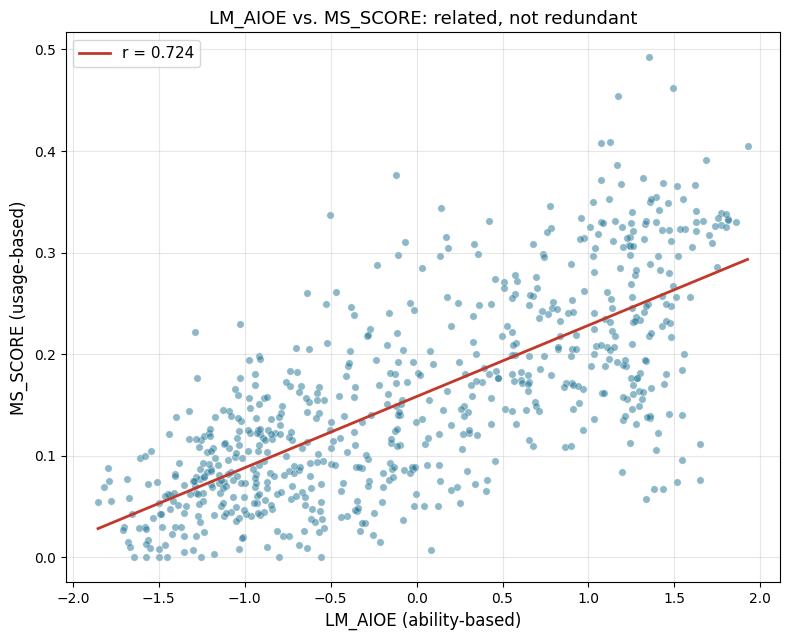

Saved index_correlation_scatter.png — correlation: 0.7239


In [6]:
corr = occ_level['LM_AIOE'].corr(occ_level['MS_SCORE'])

fig, ax = plt.subplots(figsize=(8, 6.5))
ax.scatter(occ_level['LM_AIOE'], occ_level['MS_SCORE'],
           alpha=0.5, color='#1C7293', s=28, edgecolor='white', linewidth=0.4)

# fitted line
z = np.polyfit(occ_level['LM_AIOE'], occ_level['MS_SCORE'], 1)
x_line = np.linspace(occ_level['LM_AIOE'].min(), occ_level['LM_AIOE'].max(), 100)
ax.plot(x_line, np.polyval(z, x_line), color='#C0392B', linewidth=2,
        label=f'r = {corr:.3f}')

ax.set_xlabel('LM_AIOE (ability-based)', fontsize=12)
ax.set_ylabel('MS_SCORE (usage-based)', fontsize=12)
ax.set_title('LM_AIOE vs. MS_SCORE: related, not redundant', fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('index_correlation_scatter.png', dpi=150)
plt.show()
print(f'Saved index_correlation_scatter.png — correlation: {corr:.4f}')
